# Practical Assignment 03: Performance Evaluation of Regression Models
**Name:** Sakshi Kailas Shewale| **Roll No:** 31 |**PRN:** 202401040126 **Class:** B2

**Application:** California House Price Prediction

**Task 1:** Regression models + evaluation metrics  
**Task 2:** Gradient Descent for Linear Regression

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import seaborn as sns

## 2. Load Dataset
California Housing: 20,640 samples, 8 features, target `MedHouseVal` (in $100,000).

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis

In [3]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nSummary Statistics:")
display(df.describe())

Shape: (20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Data Types:
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### Correlation heatmap
`MedInc` has the strongest positive correlation with price; Latitude/Longitude are strongly correlated with each other.

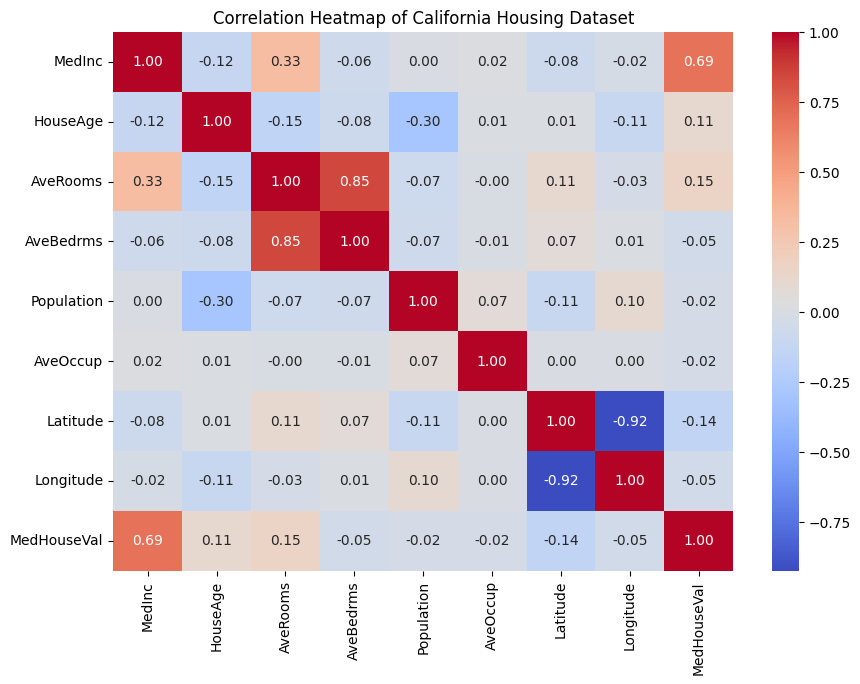

In [5]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of California Housing Dataset")
plt.show()

## 4. Train/Test Split and Feature Scaling
80/20 split; scaler is fitted on training data only to avoid leakage.

In [6]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16512
Testing samples: 4128


## 5. Task 1: Build Regression Models
Linear, Ridge (L2), Lasso (L1) and Random Forest (non-linear ensemble).

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
#Linear Regression
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

In [11]:
#Ridge Regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)

In [12]:
#Lasso Regression
lasso_model = Lasso(alpha=0.001, max_iter=10000)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)

## 6. Model Evaluation
Metrics: MAE, MSE, RMSE, R², Adjusted R².

In [13]:
#Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [14]:
#Evaluate the model
def evaluate_model(y_true, y_pred, model_name, num_features):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)

    adjusted_r2 = 1 - (
        (1 - r2) * (n - 1) / (n - num_features - 1)
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted R2": adjusted_r2
    }

In [16]:
#Now Evaluate all 4 regresion model
results = []

results.append(
    evaluate_model(
        y_test,
        linear_pred,
        "Linear Regression",
        X.shape[1]
    )
)

results.append(
    evaluate_model(
        y_test,
        ridge_pred,
        "Ridge Regression",
        X.shape[1]
    )
)

results.append(
    evaluate_model(
        y_test,
        lasso_pred,
        "Lasso Regression",
        X.shape[1]
    )
)

results.append(
    evaluate_model(
        y_test,
        rf_pred,
        "Random Forest",
        X.shape[1]
    )
)

results_df = pd.DataFrame(results)

display(results_df)


,Model,MAE,MSE,RMSE,R2,Adjusted R2
0,Linear Regression,0.533200,0.555892,0.745581,0.575788,0.574964
1,Ridge Regression,0.533193,0.555855,0.745557,0.575816,0.574992
2,Lasso Regression,0.533145,0.554491,0.744642,0.576856,0.576034
3,Random Forest,0.327543,0.255368,0.505340,0.805123,0.804745


## 7. Cross-Validation
5-fold CV R². Note: folds are unshuffled and the data is geographically ordered, which explains the lower Random Forest CV score.

In [17]:
models_cv = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001, max_iter=10000),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

cv_results = {}

for name, model in models_cv.items():

    if name == "Random Forest":
        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring="r2",
            n_jobs=-1
        )
    else:
        scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring="r2"
        )

    cv_results[name] = scores.mean()

print("5-Fold Cross Validation R²:")

for model, score in cv_results.items():
    print(f"{model}: {score:.4f}")

5-Fold Cross Validation R²:
Linear Regression: 0.5530
Ridge Regression: 0.5530
Lasso Regression: 0.5531
Random Forest: 0.6561


## 8. Diagnostic Plots
Actual vs predicted and residuals show non-linearity, heteroscedasticity and the target cap at 5.0.

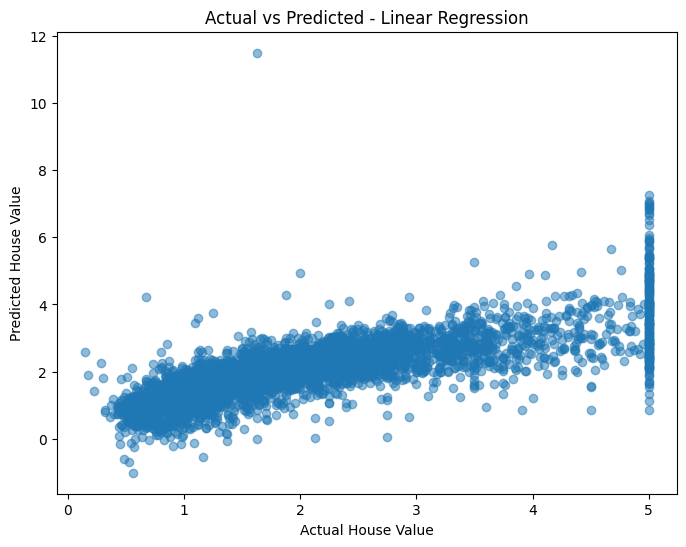

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, linear_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted - Linear Regression")

plt.show()

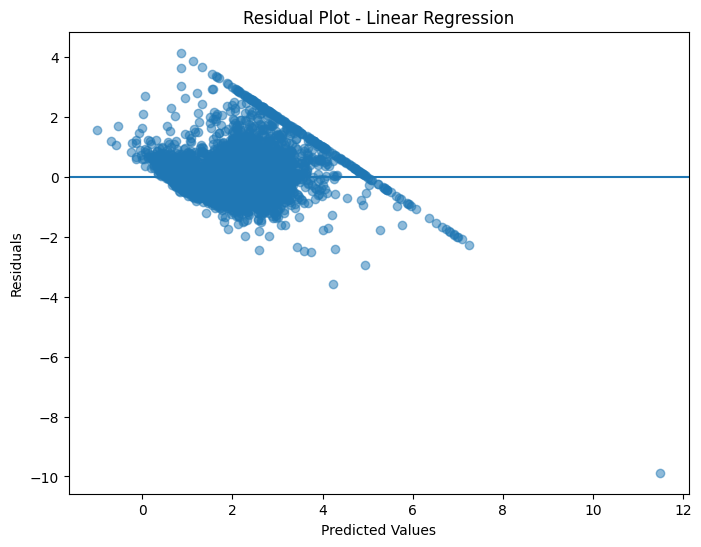

In [19]:
residuals = y_test - linear_pred

plt.figure(figsize=(8, 6))

plt.scatter(linear_pred, residuals, alpha=0.5)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.show()

## 9. Task 2: Gradient Descent from Scratch
Cost: J = 1/(2m) Σ(ŷ−y)²; update: w := w − α·∇J

In [20]:
#Part 2 Implement Gradient Descent

class GradientDescentLinearRegression:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):

            predictions = np.dot(X, self.weights) + self.bias

            errors = predictions - y

            cost = (1 / (2 * n_samples)) * np.sum(errors ** 2)

            self.cost_history.append(cost)

            dw = (1 / n_samples) * np.dot(X.T, errors)

            db = (1 / n_samples) * np.sum(errors)

            self.weights -= self.learning_rate * dw

            self.bias -= self.learning_rate * db

    def predict(self, X):

        return np.dot(X, self.weights) + self.bias

In [21]:
gd_model = GradientDescentLinearRegression(
    learning_rate=0.01,
    epochs=1000
)

gd_model.fit(X_train_scaled, y_train)

gd_pred = gd_model.predict(X_test_scaled)

In [22]:
gd_results = evaluate_model(
    y_test,
    gd_pred,
    "Gradient Descent",
    X.shape[1]
)

print(pd.DataFrame([gd_results]))

              Model       MAE       MSE      RMSE        R2  Adjusted R2
0  Gradient Descent  0.547676  0.567185  0.753117  0.567169     0.566329


### Convergence curve

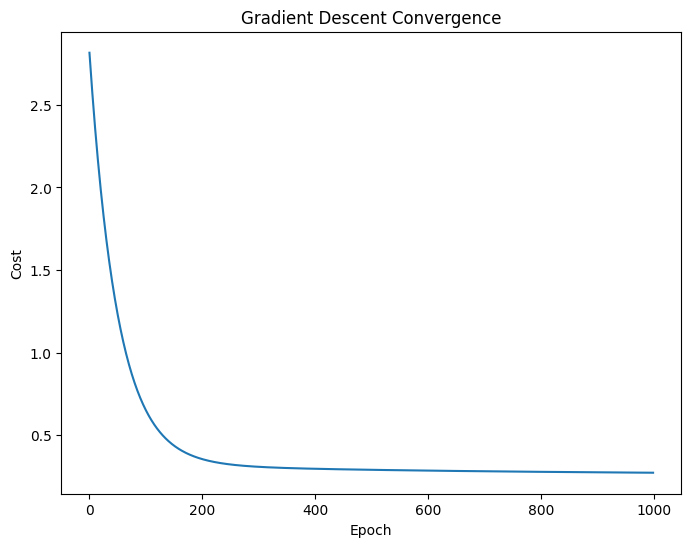

In [23]:
plt.figure(figsize=(8, 6))

plt.plot(gd_model.cost_history)

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")

plt.show()

### Effect of learning rate
α=0.001 too slow; α=0.01 slow; α=0.1 and 0.5 converge in ~30 epochs.

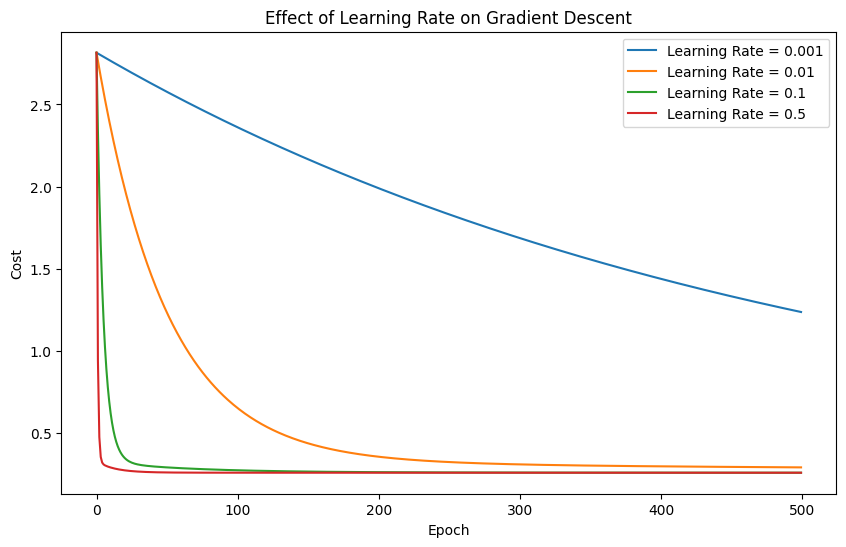

In [24]:
learning_rates = [0.001, 0.01, 0.1, 0.5]

plt.figure(figsize=(10, 6))

for lr in learning_rates:

    model = GradientDescentLinearRegression(
        learning_rate=lr,
        epochs=500
    )

    model.fit(X_train_scaled, y_train)

    plt.plot(
        model.cost_history,
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Effect of Learning Rate on Gradient Descent")

plt.legend()

plt.show()

## 10. Normal Equation (closed-form solution)

In [25]:
X_train_ne = np.c_[
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
]

X_test_ne = np.c_[
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
]

theta = np.linalg.pinv(
    X_train_ne.T @ X_train_ne
) @ X_train_ne.T @ y_train

normal_pred = X_test_ne @ theta

normal_r2 = r2_score(y_test, normal_pred)

print("Normal Equation R²:", normal_r2)

Normal Equation R²: 0.5757877060324508


## 11. Final Comparison of All Models
Random Forest is best (R² 0.805). Gradient Descent (α=0.01) is slightly below the Normal Equation because it has not fully converged.

In [26]:
final_results = results.copy()

final_results.append(gd_results)

final_results.append(
    evaluate_model(
        y_test,
        normal_pred,
        "Normal Equation",
        X.shape[1]
    )
)

final_df = pd.DataFrame(final_results)

display(final_df)

,Model,MAE,MSE,RMSE,R2,Adjusted R2
0,Linear Regression,0.533200,0.555892,0.745581,0.575788,0.574964
1,Ridge Regression,0.533193,0.555855,0.745557,0.575816,0.574992
2,Lasso Regression,0.533145,0.554491,0.744642,0.576856,0.576034
3,Random Forest,0.327543,0.255368,0.505340,0.805123,0.804745
4,Gradient Descent,0.547676,0.567185,0.753117,0.567169,0.566329
5,Normal Equation,0.533200,0.555892,0.745581,0.575788,0.574964
